In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

data = pd.read_csv('data/heart_disease_dataset.csv')

data.head(5)

,Age,Gender,Cholesterol,BloodPressure,HeartRate,Smoking,AlcoholIntake,ExerciseHours,FamilyHistory,Diabetes,Obesity,StressLevel,BloodSugar,ExerciseInducedAngina,ChestPainType,HeartDisease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    1000 non-null   int64 
 1   Gender                 1000 non-null   object
 2   Cholesterol            1000 non-null   int64 
 3   BloodPressure          1000 non-null   int64 
 4   HeartRate              1000 non-null   int64 
 5   Smoking                1000 non-null   object
 6   AlcoholIntake          660 non-null    object
 7   ExerciseHours          1000 non-null   int64 
 8   FamilyHistory          1000 non-null   object
 9   Diabetes               1000 non-null   object
 10  Obesity                1000 non-null   object
 11  StressLevel            1000 non-null   int64 
 12  BloodSugar             1000 non-null   int64 
 13  ExerciseInducedAngina  1000 non-null   object
 14  ChestPainType          1000 non-null   object
 15  HeartDisease          

# Verificar se há dados nulos

In [4]:
data.isna().sum()

Age                        0
Gender                     0
Cholesterol                0
BloodPressure              0
HeartRate                  0
Smoking                    0
AlcoholIntake            340
ExerciseHours              0
FamilyHistory              0
Diabetes                   0
Obesity                    0
StressLevel                0
BloodSugar                 0
ExerciseInducedAngina      0
ChestPainType              0
HeartDisease               0
dtype: int64

# Alterar os dados lidos como nulos na coluna 'AlcoholIntake' para seu valor original ('None')

In [5]:
data['AlcoholIntake'] = data['AlcoholIntake'].fillna('None')
data['AlcoholIntake']

0         Heavy
1          None
2         Heavy
3          None
4          None
         ...   
995       Heavy
996        None
997    Moderate
998        None
999        None
Name: AlcoholIntake, Length: 1000, dtype: object

# Alterar as respostas Yes/No para 1 e 0 e criar a coluna IsFemale com valores de 1 e 0 com base na coluna Gender

In [6]:
data['FamilyHistory'] = data['FamilyHistory'].apply(lambda x: 1 if x == "Yes" else 0)
data['Diabetes'] = data['Diabetes'].apply(lambda x: 1 if x == "Yes" else 0)
data['Obesity'] = data['Obesity'].apply(lambda x: 1 if x == "Yes" else 0)
data['ExerciseInducedAngina'] = data['ExerciseInducedAngina'].apply(lambda x: 1 if x == "Yes" else 0)
data['IsFemale'] = data['Gender'].apply(lambda x: 1 if x == "Female" else 0)

# Deletar a coluna Gender

In [7]:
data.drop('Gender', axis=1, inplace=True)


# Realizer One-Hot Encoding com get_dummies

In [8]:
data = pd.get_dummies(data, columns=['Smoking', 'AlcoholIntake', 'ChestPainType'], drop_first=True)

data.head()

,Age,Cholesterol,BloodPressure,HeartRate,ExerciseHours,FamilyHistory,Diabetes,Obesity,StressLevel,BloodSugar,ExerciseInducedAngina,HeartDisease,IsFemale,Smoking_Former,Smoking_Never,AlcoholIntake_Moderate,AlcoholIntake_None,ChestPainType_Atypical Angina,ChestPainType_Non-anginal Pain,ChestPainType_Typical Angina
0,75,228,119,66,1,0,0,1,8,119,1,1,1,False,False,False,False,True,False,False
1,48,204,165,62,5,0,0,0,9,70,1,0,0,False,False,False,True,False,False,True
2,53,234,91,67,3,1,0,1,5,196,1,1,0,False,True,False,False,True,False,False
3,69,192,90,72,4,0,1,0,7,107,1,0,1,False,False,False,True,False,True,False
4,62,172,163,93,6,0,1,0,2,183,1,0,1,False,True,False,True,False,False,False


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Age                             1000 non-null   int64
 1   Cholesterol                     1000 non-null   int64
 2   BloodPressure                   1000 non-null   int64
 3   HeartRate                       1000 non-null   int64
 4   ExerciseHours                   1000 non-null   int64
 5   FamilyHistory                   1000 non-null   int64
 6   Diabetes                        1000 non-null   int64
 7   Obesity                         1000 non-null   int64
 8   StressLevel                     1000 non-null   int64
 9   BloodSugar                      1000 non-null   int64
 10  ExerciseInducedAngina           1000 non-null   int64
 11  HeartDisease                    1000 non-null   int64
 12  IsFemale                        1000 non-null   int64
 13  Smok

# Separar colunas numéricas e binárias

In [10]:
numeric_cols = ['Age', 'Cholesterol', 'BloodPressure', 'HeartRate', 'ExerciseHours', 'StressLevel', 'BloodSugar']

binary_cols = ['FamilyHistory', 'Diabetes', 'Obesity', 'ExerciseInducedAngina', 'IsFemale', 'HeartDisease']

# Separar as features X e o target Y e realizar o split de treino e teste

In [11]:
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Normalizar as colunas numéricas

In [13]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Criar modelos

In [14]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, C=0.1, penalty='l2'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=3, min_samples_split=50, min_samples_leaf=20, min_impurity_decrease=0.01, ccp_alpha=0.01),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=50, max_depth=5, min_samples_split=50, min_samples_leaf=20, max_features='sqrt', max_samples=0.7, ccp_alpha=0.01),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=50, max_depth=2, learning_rate=0.05, min_samples_split=50, min_samples_leaf=20, subsample=0.7, max_features='sqrt'),
    'SVM': SVC(random_state=42, probability=True, C=0.5, kernel='rbf', gamma='scale'),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Naive Bayes': GaussianNB()
}

# Treinar e avaliar modelos 

In [ ]:
results = []

for name, model in models.items():

  #Validação Cruzada

  cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

  #Treinamento
  model.fit(X_train_scaled, y_train)

  #Predição
  y_pred = model.predict(X_test_scaled)
  y_pred_proba = model.predict_proba(X_test_scaled)[:,1] if hasattr(model,'predict_proba') else None

  #Métricas
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

  #Armazenamento
  results.append({
    'Model': name,
    'CV_Mean': cv_scores.mean(),
    'CV_Std': cv_scores.std(),
    'Test_Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'ROC-AUC':roc_auc
  })

  print(f"\n{'='*40}")
  print(f"Modelo: {name}")
  print(f"{'='*40}")
  print(f"Acurácia Validação Cruzada: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
  print(f"Acurácia Teste:  {accuracy:.4f}")
  print(f"Precisão: {precision:.4f}")
  print(f"Recall:    {recall:.4f}")
  print(f"F1-Score:  {f1:.4f}")
  if roc_auc:
      print(f"ROC-AUC:   {roc_auc:.4f}")

  #Matriz de Confusão
  print(f'\nConfusion Matrix:')
  print(confusion_matrix(y_test,y_pred))




Modelo: Logistic Regression
Acurácia Validação Cruzada: 0.8514 (+/- 0.0146)
Acurácia Teste:  0.8767
Precisão: 0.8785
Recall:    0.7966
F1-Score:  0.8356
ROC-AUC:   0.9590

Confusion Matrix:
[[169  13]
 [ 24  94]]

Modelo: Decision Tree
Acurácia Validação Cruzada: 0.9986 (+/- 0.0029)
Acurácia Teste:  1.0000
Precisão: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Confusion Matrix:
[[182   0]
 [  0 118]]

Modelo: Random Forest
Acurácia Validação Cruzada: 0.9986 (+/- 0.0029)
Acurácia Teste:  0.9967
Precisão: 1.0000
Recall:    0.9915
F1-Score:  0.9957
ROC-AUC:   1.0000

Confusion Matrix:
[[182   0]
 [  1 117]]

Modelo: Gradient Boosting
Acurácia Validação Cruzada: 0.9943 (+/- 0.0053)
Acurácia Teste:  0.9967
Precisão: 1.0000
Recall:    0.9915
F1-Score:  0.9957
ROC-AUC:   1.0000

Confusion Matrix:
[[182   0]
 [  1 117]]

Modelo: SVM
Acurácia Validação Cruzada: 0.9043 (+/- 0.0073)
Acurácia Teste:  0.9300
Precisão: 0.9450
Recall:    0.8729
F1-Score:  0.9075
ROC-AUC:   0.9857

C

# Gráficos e comparação de resultados


COMPARAÇÃO: Validação Cruzada vs Teste
              Model  CV_Mean  Test_Accuracy       F1
      Decision Tree 0.998571       1.000000 1.000000
      Random Forest 0.998571       0.996667 0.995745
  Gradient Boosting 0.994286       0.996667 0.995745
        Naive Bayes 0.908571       0.936667 0.914027
                SVM 0.904286       0.930000 0.907489
                KNN 0.898571       0.930000 0.905830
Logistic Regression 0.851429       0.876667 0.835556


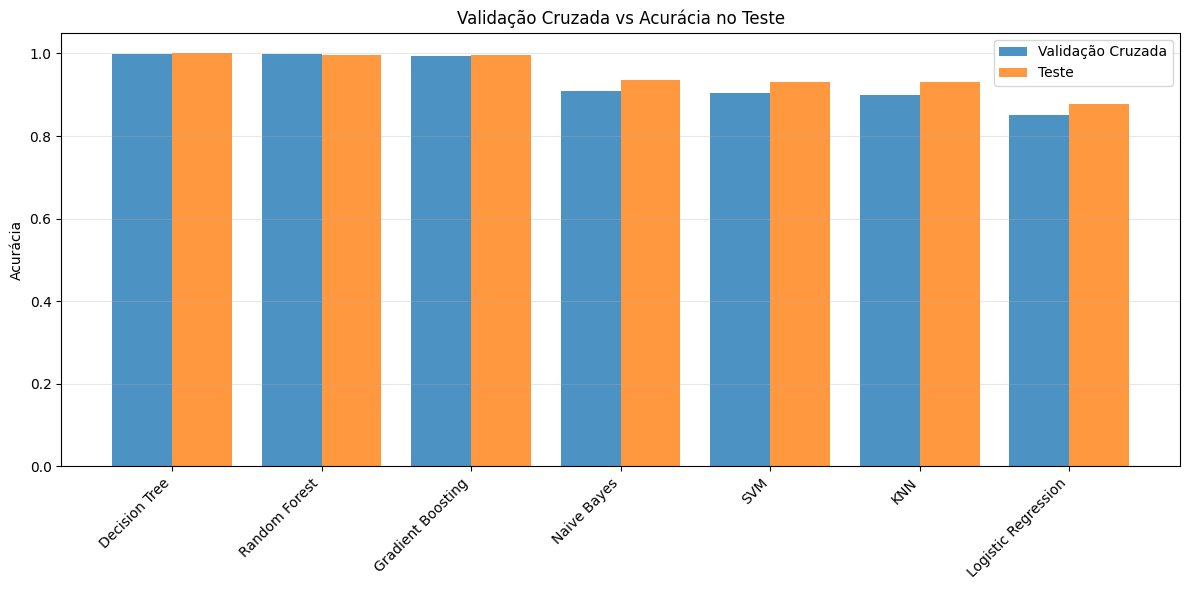

In [21]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_Accuracy', ascending=False)


print(f"\n{'='*60}")
print("COMPARAÇÃO: Validação Cruzada vs Teste")
print(f"{'='*60}")
print(results_df[['Model', 'CV_Mean', 'Test_Accuracy', 'F1']].to_string(index=False))

# Gráfico comparando CV vs Test
plt.figure(figsize=(12, 6))
x = range(len(results_df))
plt.bar([i - 0.2 for i in x], results_df['CV_Mean'], width=0.4, label='Validação Cruzada', alpha=0.8)
plt.bar([i + 0.2 for i in x], results_df['Test_Accuracy'], width=0.4, label='Teste', alpha=0.8)
plt.xticks(x, results_df['Model'], rotation=45, ha='right')
plt.ylabel('Acurácia')
plt.title('Validação Cruzada vs Acurácia no Teste')
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

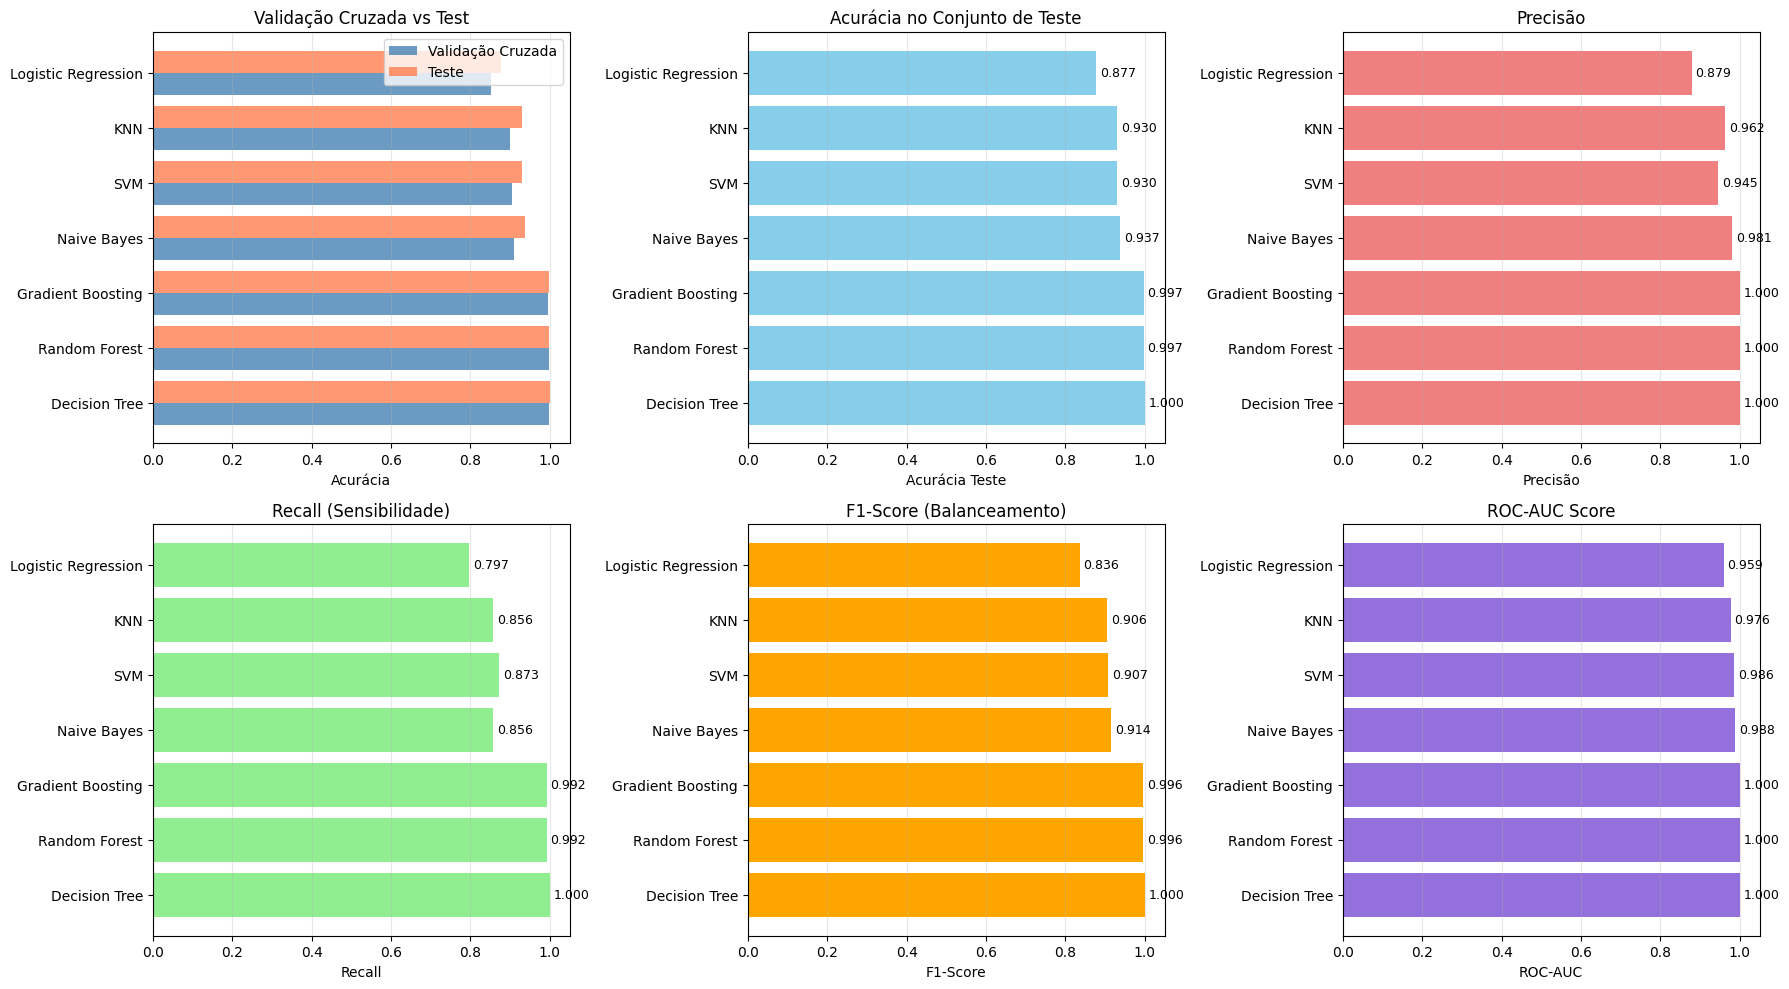

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Comparação Validação Cruzada vs Teste
x_pos = range(len(results_df))
axes[0, 0].barh([i - 0.2 for i in x_pos], results_df['CV_Mean'], 
                height=0.4, label='Validação Cruzada', color='steelblue', alpha=0.8)
axes[0, 0].barh([i + 0.2 for i in x_pos], results_df['Test_Accuracy'], 
                height=0.4, label='Teste', color='coral', alpha=0.8)
axes[0, 0].set_yticks(x_pos)
axes[0, 0].set_yticklabels(results_df['Model'])
axes[0, 0].set_xlabel('Acurácia')
axes[0, 0].set_title('Validação Cruzada vs Test')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 1.05)
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Accurácia Teste
axes[0, 1].barh(results_df['Model'], results_df['Test_Accuracy'], color='skyblue')
axes[0, 1].set_xlabel('Acurácia Teste')
axes[0, 1].set_title('Acurácia no Conjunto de Teste')
axes[0, 1].set_xlim(0, 1.05)
for i, v in enumerate(results_df['Test_Accuracy']):
    axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Precision
axes[0, 2].barh(results_df['Model'], results_df['Precision'], color='lightcoral')
axes[0, 2].set_xlabel('Precisão')
axes[0, 2].set_title('Precisão')
axes[0, 2].set_xlim(0, 1.05)
for i, v in enumerate(results_df['Precision']):
    axes[0, 2].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[0, 2].grid(axis='x', alpha=0.3)

# 4. Recall
axes[1, 0].barh(results_df['Model'], results_df['Recall'], color='lightgreen')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_title('Recall (Sensibilidade)')
axes[1, 0].set_xlim(0, 1.05)
for i, v in enumerate(results_df['Recall']):
    axes[1, 0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1, 0].grid(axis='x', alpha=0.3)

# 5. F1-Score
axes[1, 1].barh(results_df['Model'], results_df['F1'], color='orange')
axes[1, 1].set_xlabel('F1-Score')
axes[1, 1].set_title('F1-Score (Balanceamento)')
axes[1, 1].set_xlim(0, 1.05)
for i, v in enumerate(results_df['F1']):
    axes[1, 1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1, 1].grid(axis='x', alpha=0.3)

# 6. ROC-AUC
axes[1, 2].barh(results_df['Model'], results_df['ROC-AUC'], color='mediumpurple')
axes[1, 2].set_xlabel('ROC-AUC')
axes[1, 2].set_title('ROC-AUC Score')
axes[1, 2].set_xlim(0, 1.05)
for i, v in enumerate(results_df['ROC-AUC']):
    if pd.notna(v):
        axes[1, 2].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1, 2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

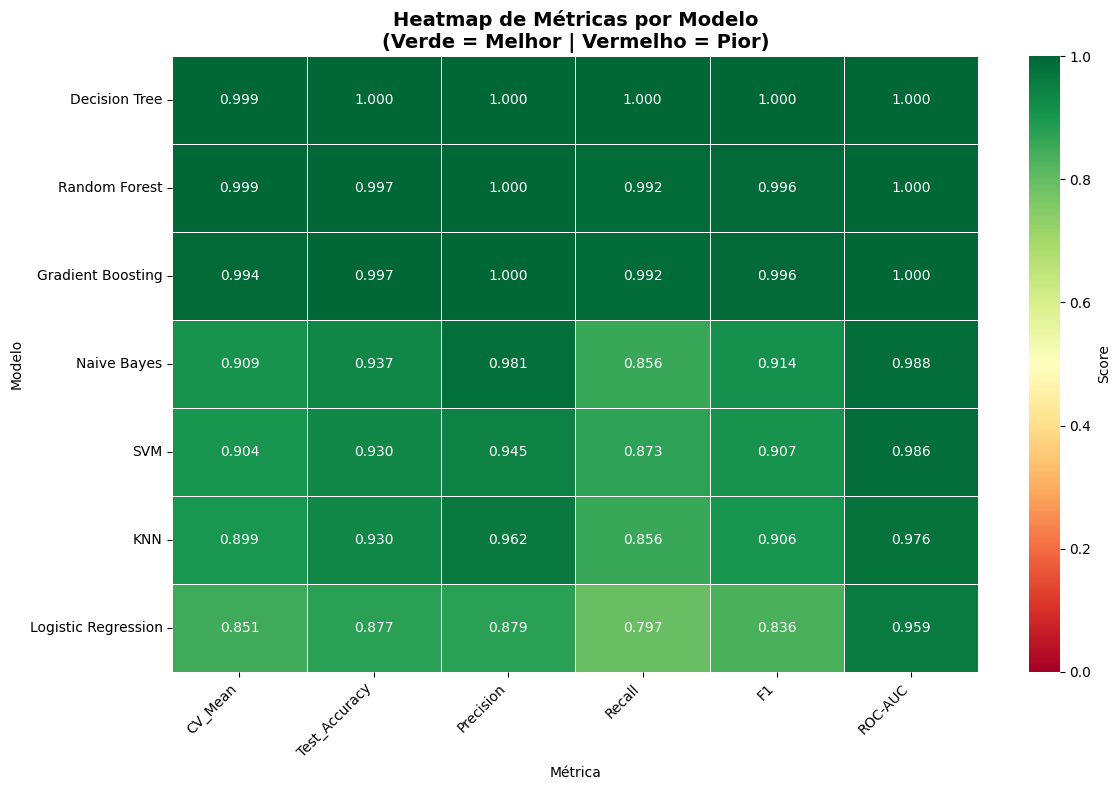

In [ ]:
# Heatmap de Métricas

plt.figure(figsize=(12, 8))

# Selecionar apenas colunas numéricas
metrics_cols = ['CV_Mean', 'Test_Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
heatmap_data = results_df[['Model'] + metrics_cols].set_index('Model')

# Criar heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'Score'})
plt.title('Heatmap de Métricas por Modelo\n(Verde = Melhor | Vermelho = Pior)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Métrica')
plt.ylabel('Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Melhor modelo

Após analisar métricas e realizar alterações de parâmetros, ficou claro que os modelos de Árvore de Decisão, Floresta de Decisão Aleatória e Gradient Boosting apresentam sinais de overfitting. Isso pode ter acontecido devido ao dataset limitado (1000 registros) e levado os modelos a se familiarizarem com os dados, onde apresentariam um mal desempenho caso fossem aplicados a um novo conjunto de dados por não conseguirem se adaptar.

A partir disso, concluí que o melhor modelo para a classificação de "Há probabilidade do paciente ter uma doença cardíaca?" é o modelo Naive Bayes. Ele apresentou excelente capacidade de discriminação (ROC-AUC de 0.988) e o F1-Score mais alto entre os não overfitted (0.914), detectou 85.6% dos doentes (recall de 0.856), acertou em 98.1% das vezes em que alguém tinha a condição médica (precisão de 0.981) e se mostrou interpretável e sem sinais de overfitting. Em outras palavras, é o melhor modelo para solucionar o problema pois detecta a maioria dos doentes com poucos alarmes falsos e apresenta o melhor balanceamento, sendo o mais adequado para uma aplicação clínica. 